# ITCHI synthetic smoke test

This notebook validates the basic end-to-end workflow of `itchi-core` using synthetic data.

The goal is not physical realism, but to confirm that the current API can:

1. build synthetic precipitation snapshots;
2. compute ITCHI for each snapshot;
3. compile a simple event;
4. compute `ITCHI_max` and `ITCHI_acc`;
5. inspect spatial outputs and metadata.


## 1. Imports


In [1]:
import matplotlib.pyplot as plt
import numpy as np

from itchi.compiler import compile_itchi_event


## 2. Synthetic grid

We create a small regular lon/lat grid around a synthetic cyclone center.


In [2]:
lon_1d = np.linspace(-2.0, 2.0, 81)
lat_1d = np.linspace(-2.0, 2.0, 81)

lon, lat = np.meshgrid(lon_1d, lat_1d)

lon.shape, lat.shape


((81, 81), (81, 81))

## 3. Synthetic precipitation snapshots

The precipitation field is treated as a snapshot, not as an accumulated field.


In [ ]:
def synthetic_precipitation(lon, 
                            lat, 
                            center_lon, 
                            center_lat, 
                            amplitude=35.0, 
                            sigma=0.55):
    """Build a synthetic precipitation snapshot."""
    distance2 = (lon - center_lon) ** 2 + (lat - center_lat) ** 2
    core = amplitude * np.exp(-distance2 / (2.0 * sigma**2))
    background = 5.0
    return background + core


precip_00 = synthetic_precipitation(lon, lat, center_lon=-0.3, center_lat=0.0)
precip_06 = synthetic_precipitation(lon, lat, center_lon=0.3, center_lat=0.2)

precip_00.min(), precip_00.max(), precip_06.min(), precip_06.max()


(np.float64(5.000007504379013),
 np.float64(40.0),
 np.float64(5.000001872092832),
 np.float64(40.0))

## 4. Build snapshot inputs

For this smoke test we use fixed percentile thresholds and complete quadrant radii.

- `R34` is provided in nautical miles.
- `ROCLOUD` is provided in kilometers.
- Wind hazard is computed internally from `vmax_kt` and `rmw_km`.


In [ ]:
def make_snapshot_input(precipitation,
                         center_lon, 
                         center_lat, 
                         vmax_kt=80.0, 
                         rmw_km=25.0):
    return {
        "precipitation": precipitation,
        "q90": 10.0,
        "q95": 20.0,
        "q99": 30.0,
        "lon": lon,
        "lat": lat,
        "center_lon": center_lon,
        "center_lat": center_lat,
        "r34_by_quadrant": {
            "RNE": 45.0,
            "RSE": 40.0,
            "RSW": 35.0,
            "RNW": 50.0,
        },
        "r34_unit": "nm",
        "rocloud_by_quadrant": {
            "RNE": 250.0,
            "RSE": 230.0,
            "RSW": 220.0,
            "RNW": 260.0,
        },
        "rocloud_unit": "km",
        "wind_hazard_normalized": None,
        "vmax_kt": vmax_kt,
        "rmw_km": rmw_km,
        "run_quality_control": True,
    }


snapshot_inputs = [
    make_snapshot_input(precip_00, center_lon=-0.3, center_lat=0.0),
    make_snapshot_input(precip_06, center_lon=0.3, center_lat=0.2),
]

time_values = ["2020-09-01T00:00", "2020-09-01T06:00"]


## 5. Compile synthetic event


In [5]:
compiled = compile_itchi_event(
    snapshot_inputs=snapshot_inputs,
    time_values=time_values,
)

compiled.keys()


dict_keys(['snapshots', 'metadata', 'event_products'])

In [6]:
compiled["snapshots"].keys(), compiled["event_products"].keys()


(dict_keys(['radius_km', 'quadrant', 'R_direct_q', 'ROCLOUD_q', 'M_direct', 'M_indirect', 'M_exterior', 'H_P', 'H_Pdir', 'H_Pind', 'H_W', 'H_dir', 'H_ind', 'ITCHI']),
 dict_keys(['ITCHI_max', 'ITCHI_acc']))

## 6. Inspect metadata


In [7]:
compiled["metadata"]


[{'time': '2020-09-01T00:00',
  'R_direct_source': 'R34',
  'R_direct_filled_quadrants': (),
  'R_direct_used_fallback': False,
  'ROCLOUD_source': 'observed',
  'ROCLOUD_filled_quadrants': (),
  'wind_hazard_source': 'radial_profile'},
 {'time': '2020-09-01T06:00',
  'R_direct_source': 'R34',
  'R_direct_filled_quadrants': (),
  'R_direct_used_fallback': False,
  'ROCLOUD_source': 'observed',
  'ROCLOUD_filled_quadrants': (),
  'wind_hazard_source': 'radial_profile'}]

## 7. Basic numerical checks


In [8]:
itchi = compiled["snapshots"]["ITCHI"]
itchi_max = compiled["event_products"]["ITCHI_max"]
itchi_acc = compiled["event_products"]["ITCHI_acc"]

print("ITCHI shape:", itchi.shape)
print("ITCHI min/max:", np.nanmin(itchi), np.nanmax(itchi))
print("ITCHI_max min/max:", np.nanmin(itchi_max), np.nanmax(itchi_max))
print("ITCHI_acc min/max:", np.nanmin(itchi_acc), np.nanmax(itchi_acc))


ITCHI shape: (2, 81, 81)
ITCHI min/max: 0.0 1.0
ITCHI_max min/max: 0.0 1.0
ITCHI_acc min/max: 0.0 1.0


## 8. Quick visualization


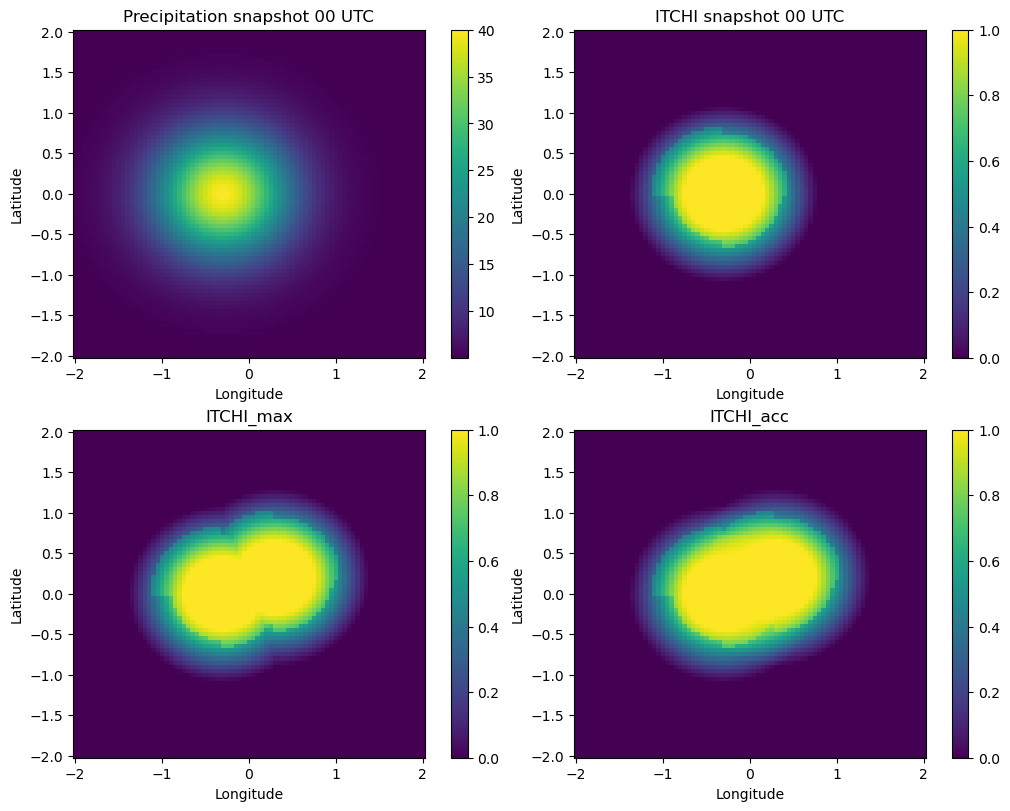

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8), constrained_layout=True)

plots = [
    (precip_00, "Precipitation snapshot 00 UTC"),
    (itchi[0], "ITCHI snapshot 00 UTC"),
    (itchi_max, "ITCHI_max"),
    (itchi_acc, "ITCHI_acc"),
]

for ax, (field, title) in zip(axes.ravel(), plots, strict=False):
    im = ax.pcolormesh(lon, lat, field, shading="auto")
    ax.set_title(title)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    fig.colorbar(im, ax=ax)

plt.show()


## 9. Interpretation

This synthetic notebook confirms that the current repository can execute the full ITCHI workflow for a simple event.

The next step is to add a script version under `examples/` so the same workflow can be executed from terminal without opening Jupyter.
